In [237]:
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Global aesthetic settings
plt.rcParams["figure.dpi"] = 120  # Crisp resolution

sns.set_theme(
    style="ticks",
    font="sans-serif",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.bottom": True,
        "ytick.left": True,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)

In [238]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [239]:
# ============================================================
# Files to download from the drives data folder
# ============================================================
filenames = [
    "listings_relevant_clean_price_p99.csv",
]

In [240]:
# ============================================================
# Background logic for download needed once per Colab notebook
# ============================================================
from pathlib import Path
import io

from tqdm.auto import tqdm

from google.colab import auth
auth.authenticate_user()

from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

drive_service = build("drive", "v3")

# Paste the Data folder ID printed by the previous upload script
DATA_FOLDER_ID = "15o0Cq15Uqy_oeWQ9egCcKVv2fi6W5Iu9"

LOCAL_DATA_DIR = Path("/content/data")
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)


def find_file_in_folder(filename: str, folder_id: str) -> str:
    query = (
        f"name = '{filename}' "
        f"and '{folder_id}' in parents "
        f"and trashed = false"
    )

    results = drive_service.files().list(
        q=query,
        fields="files(id, name, size)",
        supportsAllDrives=True,
        includeItemsFromAllDrives=True,
    ).execute()

    files = results.get("files", [])

    if not files:
        raise FileNotFoundError(f"Could not find {filename} in Drive data folder.")

    return files[0]["id"]


def download_drive_file(file_id: str, local_path: Path):
    request = drive_service.files().get_media(
        fileId=file_id,
        supportsAllDrives=True,
    )

    with open(local_path, "wb") as f:
        downloader = MediaIoBaseDownload(f, request)

        done = False
        with tqdm(unit="B", unit_scale=True, desc=local_path.name) as progress:
            previous_bytes = 0

            while not done:
                status, done = downloader.next_chunk()

                if status:
                    current_bytes = int(status.resumable_progress)
                    progress.update(current_bytes - previous_bytes)
                    previous_bytes = current_bytes


# Download files from Google Drive/data to local Colab runtime
for filename in filenames:
    local_path = LOCAL_DATA_DIR / filename

    # if local_path.exists():
    #     print(f"Skipping {filename}, already downloaded locally.")
    #     continue

    print(f"Finding {filename} in Drive...")
    file_id = find_file_in_folder(filename, DATA_FOLDER_ID)

    print(f"Downloading {filename} to {local_path}...")
    download_drive_file(file_id, local_path)

print("\nFiles available locally in:")
print(LOCAL_DATA_DIR)
!ls "data"

Finding listings_relevant_clean_price_p99.csv in Drive...


listings_relevant_clean_price_p99.csv: 0.00B [00:00, ?B/s]


Files available locally in:
/content/data
listings_relevant_clean_price_p99.csv


In [241]:
df = pd.read_csv("data/listings_relevant_clean_price_p99.csv")

In [242]:
X = df["distance_km"].to_numpy()
y = df["price"].to_numpy()
print(X.T)

[6.84714408 1.80560895 4.82923865 ... 2.35103357 2.73805961 2.68423387]


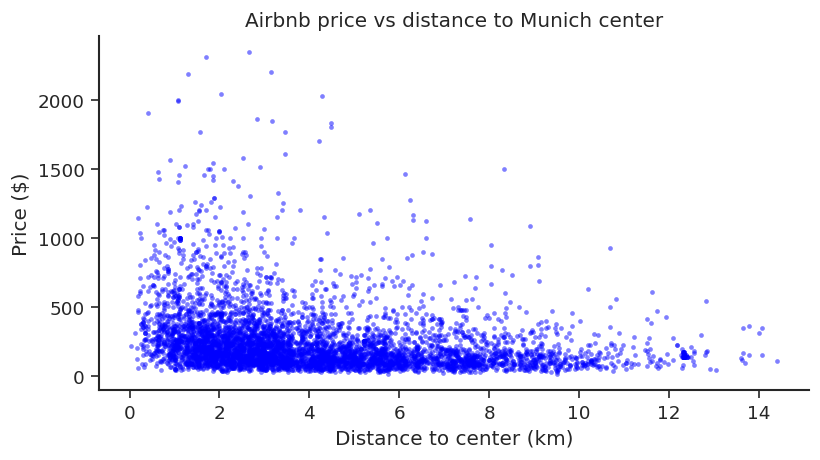

In [243]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(
    x=X,
    y=y,
    s=8,
    color="blue",
    alpha=0.5,
    linewidth=0,
    ax=ax
)

ax.set_xlabel("Distance to center (km)")
ax.set_ylabel("Price ($)")
ax.set_title("Airbnb price vs distance to Munich center")

plt.tight_layout()
plt.show()

In [244]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing, 80% for training
    random_state=727,
    shuffle = True
)

In [245]:
model = LinearRegression().fit(X_train.reshape(-1, 1), y_train) #Expects 2D input -> reshape x

w = model.coef_[0]
print("w", w)
b = model.intercept_
print("b", b)

y_pred_test = model.predict(X_test.reshape(-1,1))

w -21.105545511972352
b 337.05518578388615


In [246]:
mse = mean_squared_error(y_test, y_pred_test)   # Mean Squared Error
r2 = r2_score(y_test, y_pred_test)              # Same as model.score()
print(mse, r2)

40307.101562422344 0.07303940545004728


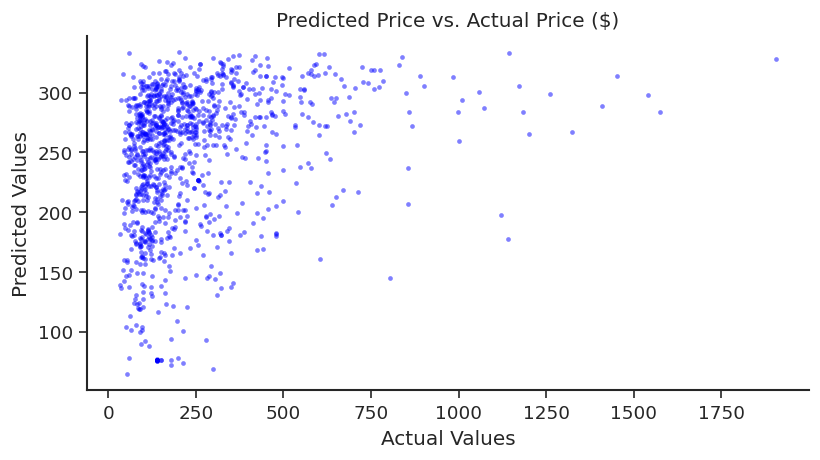

In [247]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    x=y_test,
    y=y_pred_test,
    s=8,
    color="blue",
    alpha=0.5,
    linewidth=0,
    ax=ax
)
ax.set_xlabel("Actual Values")
ax.set_ylabel("Predicted Values")
ax.set_title("Predicted Price vs. Actual Price ($)")

plt.tight_layout()
plt.show()